# TP ROBUSTESSE & IMPUTATION

## Récupération des données et modèles

In [16]:
import os
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

load_dotenv()

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PATH_DATA_ENV = os.getenv("PATH_DATA")
if PATH_DATA_ENV:
    DATA_DIR = Path(PATH_DATA_ENV)
else:
    DATA_DIR = PROJECT_ROOT / "data"

MODELS_DIR = PROJECT_ROOT / "models"
ARTIFACTS_DIR = MODELS_DIR / "imputation"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR={DATA_DIR}")
print(f"MODELS_DIR={MODELS_DIR}")
print(f"ARTIFACTS_DIR={ARTIFACTS_DIR}")

DATA_DIR=/home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet/data
MODELS_DIR=/home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet/models
ARTIFACTS_DIR=/home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet/models/imputation


In [17]:
df = pd.read_csv(DATA_DIR / "earthquake_data.csv")

colonnes_a_supprimer = [
    "title", "date_time", "net", "magType", "latitude", "longitude", "location", "continent", "country"
]
df_clean = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])

df_alert = df_clean.dropna(subset=["alert"]).copy()
df_sig = df_clean.drop(columns=["alert"]) if "alert" in df_clean.columns else df_clean.copy()

print("Shape clean:", df_clean.shape)
print("Shape alert:", df_alert.shape)
print("Shape sig:", df_sig.shape)

df_clean.head()

Shape clean: (782, 10)
Shape alert: (415, 10)
Shape sig: (782, 9)


,magnitude,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,depth
0,7.0,8,7,green,1,768,117,0.509,17.0,14.000
1,6.9,4,4,green,0,735,99,2.229,34.0,25.000
2,7.0,3,3,green,1,755,147,3.125,18.0,579.000
3,7.3,5,5,green,1,833,149,1.865,21.0,37.000
4,6.6,0,2,green,1,670,131,4.998,27.0,624.464


In [18]:
def build_preprocessor(X_train: pd.DataFrame, X_test: pd.DataFrame):
    numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    imputer_num = SimpleImputer(strategy="median")
    imputer_cat = SimpleImputer(strategy="most_frequent") if categorical_cols else None

    X_train_num = pd.DataFrame(imputer_num.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)
    X_test_num = pd.DataFrame(imputer_num.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

    if categorical_cols:
        X_train_cat = pd.DataFrame(imputer_cat.fit_transform(X_train[categorical_cols]), columns=categorical_cols, index=X_train.index)
        X_test_cat = pd.DataFrame(imputer_cat.transform(X_test[categorical_cols]), columns=categorical_cols, index=X_test.index)
        X_train_imp = pd.concat([X_train_num, X_train_cat], axis=1)[X_train.columns]
        X_test_imp = pd.concat([X_test_num, X_test_cat], axis=1)[X_test.columns]
    else:
        X_train_imp = X_train_num[X_train.columns]
        X_test_imp = X_test_num[X_test.columns]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    artifacts = {
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "imputer_num": imputer_num,
        "imputer_cat": imputer_cat,
        "scaler": scaler,
        "feature_order": X_train.columns.tolist(),
    }
    return X_train_imp, X_test_imp, X_train_scaled, X_test_scaled, artifacts

In [19]:
X_alert = df_alert.drop(columns=["alert"])
y_alert = df_alert["alert"]

X_sig = df_sig.drop(columns=["sig"])
y_sig = df_sig["sig"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_alert, y_alert, test_size=0.2, random_state=42, stratify=y_alert
)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sig, y_sig, test_size=0.2, random_state=42
)

(
    X_train_a_imp,
    X_test_a_imp,
    X_train_a_scaled,
    X_test_a_scaled,
    preproc_alert,
) = build_preprocessor(X_train_a, X_test_a)

(
    X_train_s_imp,
    X_test_s_imp,
    X_train_s_scaled,
    X_test_s_scaled,
    preproc_sig,
) = build_preprocessor(X_train_s, X_test_s)

print("Alert train/test:", X_train_a_scaled.shape, X_test_a_scaled.shape)
print("Sig train/test:", X_train_s_scaled.shape, X_test_s_scaled.shape)

Alert train/test: (332, 9) (83, 9)
Sig train/test: (625, 8) (157, 8)


## Test de robustesse

In [20]:
from sklearn.metrics import f1_score as _f1_score

def build_threshold_grid(scores: np.ndarray, n_thresholds: int = 120):
    s_min = float(np.min(scores))
    s_max = float(np.max(scores))
    if np.isclose(s_min, s_max):
        return np.array([s_min], dtype=float)
    return np.linspace(s_min, s_max, n_thresholds)


def regression_robustness_curve(
    scores: np.ndarray,
    y_true: pd.Series,
    y_pred: np.ndarray,
    thresholds: np.ndarray,
):
    y_true_np = np.asarray(y_true)
    y_pred_np = np.asarray(y_pred)
    rows = []

    for th in thresholds:
        mask = scores >= th
        coverage = float(mask.mean())

        if mask.sum() == 0:
            rmse = np.nan
        else:
            rmse = float(np.sqrt(mean_squared_error(y_true_np[mask], y_pred_np[mask])))

        rows.append({
            "threshold": float(th),
            "rmse": rmse,
            "coverage": coverage,
            "n_kept": int(mask.sum()),
        })

    return pd.DataFrame(rows)


def classification_error_curve(
    scores: np.ndarray,
    y_true: pd.Series,
    y_pred: np.ndarray,
    thresholds: np.ndarray,
    classes=None,
):
    """Retourne, pour chaque seuil, le taux d'erreur 1 - F1 par classe."""
    y_true_np = np.asarray(y_true)
    y_pred_np = np.asarray(y_pred)
    if classes is None:
        classes = sorted(np.unique(y_true_np))
    rows = []

    for th in thresholds:
        mask = scores >= th
        coverage = float(mask.mean())
        row = {"threshold": float(th), "coverage": coverage, "n_kept": int(mask.sum())}

        if mask.sum() == 0:
            for cls in classes:
                row[f"f1_error_{cls}"] = np.nan
        else:
            f1s = _f1_score(
                y_true_np[mask], y_pred_np[mask],
                labels=classes, average=None, zero_division=0,
            )
            for cls, f1 in zip(classes, f1s):
                row[f"f1_error_{cls}"] = 1.0 - float(f1)

        rows.append(row)

    return pd.DataFrame(rows)


iso_alert = IsolationForest(random_state=42, contamination="auto")
iso_sig = IsolationForest(random_state=42, contamination="auto")

iso_alert.fit(X_train_a_scaled)
iso_sig.fit(X_train_s_scaled)

scores_alert = iso_alert.score_samples(X_test_a_scaled)
scores_sig = iso_sig.score_samples(X_test_s_scaled)

threshold_grid_alert = build_threshold_grid(scores_alert, n_thresholds=120)
threshold_grid_sig = build_threshold_grid(scores_sig, n_thresholds=120)

print(f"Range scores alert: [{scores_alert.min():.6f}, {scores_alert.max():.6f}]")
print(f"Range scores sig:   [{scores_sig.min():.6f}, {scores_sig.max():.6f}]")
print(f"Nb seuils alert: {len(threshold_grid_alert)}")
print(f"Nb seuils sig:   {len(threshold_grid_sig)}")


Range scores alert: [-0.572488, -0.364547]
Range scores sig:   [-0.643583, -0.394927]
Nb seuils alert: 120
Nb seuils sig:   120


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import root_mean_squared_error

# Recherche simple d'hyperparamètres pour LogisticRegression
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=200)
gs_lr = GridSearchCV(lr, param_grid_lr, cv=3)
gs_lr.fit(X_train_a_scaled, y_train_a)
y_pred_a = gs_lr.predict(X_test_a_scaled)
print('Classification report (alert):\n', classification_report(y_test_a, y_pred_a))

# Recherche simple d'hyperparamètres pour RandomForestRegressor
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [3, 5, None]}
rf = RandomForestRegressor(random_state=42)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=3)
gs_rf.fit(X_train_s_scaled, y_train_s)
y_pred_s = gs_rf.predict(X_test_s_scaled)
print('RMSE (sig):', root_mean_squared_error(y_test_s, y_pred_s))

Classification report (alert):
               precision    recall  f1-score   support

       green       0.91      0.98      0.95        65
      orange       0.71      1.00      0.83         5
         red       1.00      1.00      1.00         2
      yellow       1.00      0.36      0.53        11

    accuracy                           0.90        83
   macro avg       0.91      0.84      0.83        83
weighted avg       0.92      0.90      0.89        83

RMSE (sig): 252.64247498817937


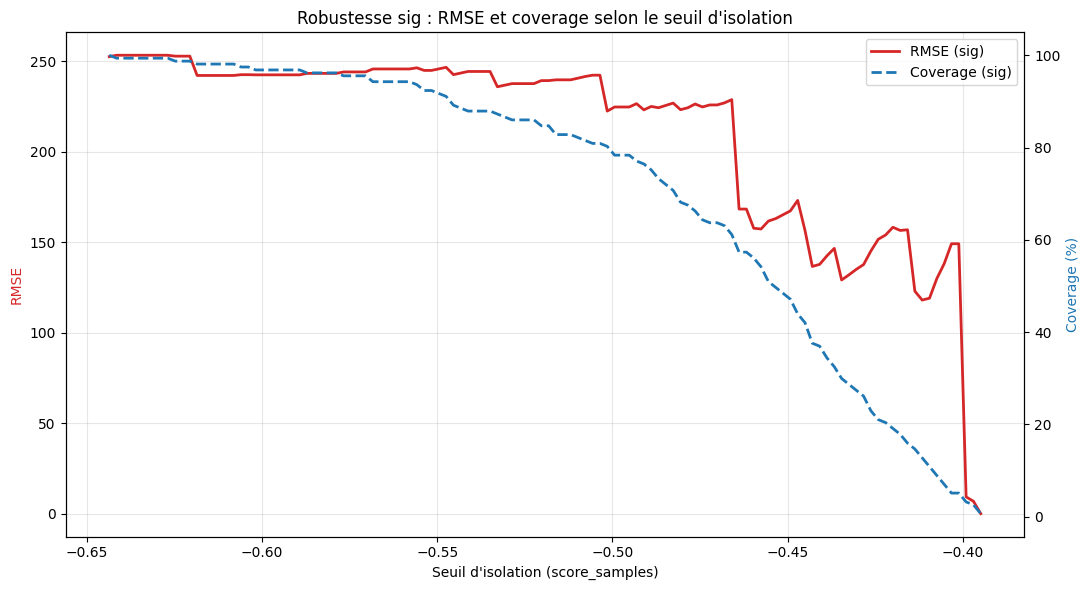

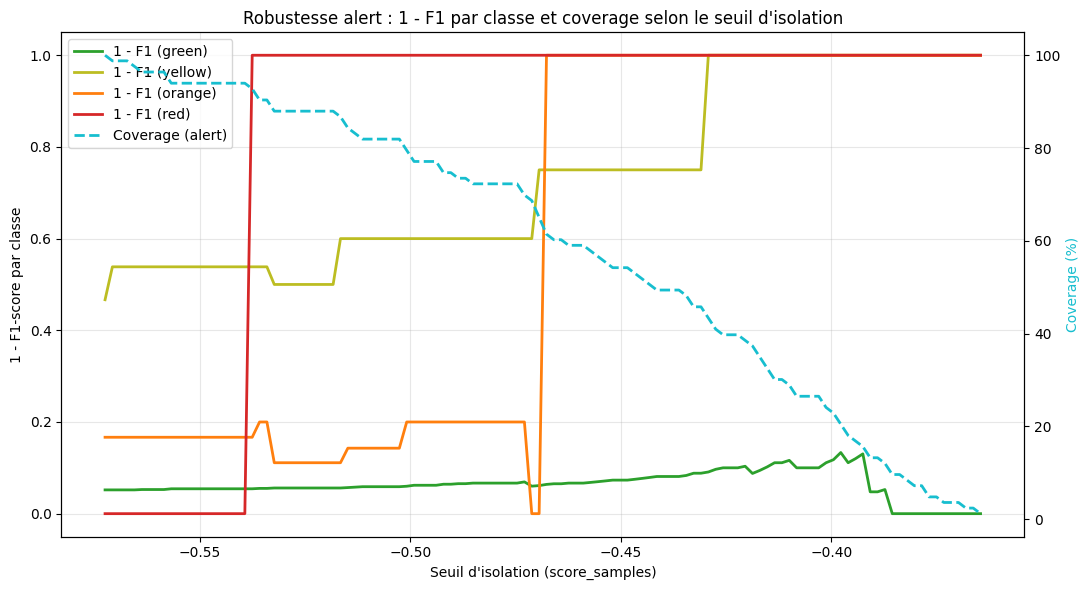

In [22]:
model_alert = gs_lr.best_estimator_
model_sig = gs_rf.best_estimator_

y_pred_alert_all = model_alert.predict(X_test_a_scaled)
y_pred_sig_all = model_sig.predict(X_test_s_scaled)

ALERT_CLASSES = ["green", "yellow", "orange", "red"]

robustness_alert = classification_error_curve(
    scores_alert,
    y_test_a,
    y_pred_alert_all,
    threshold_grid_alert,
    classes=ALERT_CLASSES,
)
robustness_sig = regression_robustness_curve(
    scores_sig,
    y_test_s,
    y_pred_sig_all,
    threshold_grid_sig,
)

# --- Courbe robuste pour SIG ---
fig, ax_rmse_sig = plt.subplots(figsize=(11, 6))
ax_cov_sig = ax_rmse_sig.twinx()

ax_rmse_sig.plot(
    robustness_sig["threshold"],
    robustness_sig["rmse"],
    color="#d62728",
    linewidth=2.0,
    label="RMSE (sig)",
)
ax_cov_sig.plot(
    robustness_sig["threshold"],
    robustness_sig["coverage"] * 100,
    color="#1f77b4",
    linewidth=2.0,
    linestyle="--",
    label="Coverage (sig)",
)

ax_rmse_sig.set_xlabel("Seuil d'isolation (score_samples)")
ax_rmse_sig.set_ylabel("RMSE", color="#d62728")
ax_cov_sig.set_ylabel("Coverage (%)", color="#1f77b4")
ax_rmse_sig.set_title("Robustesse sig : RMSE et coverage selon le seuil d'isolation")
ax_rmse_sig.grid(True, alpha=0.3)

lines_1, labels_1 = ax_rmse_sig.get_legend_handles_labels()
lines_2, labels_2 = ax_cov_sig.get_legend_handles_labels()
ax_rmse_sig.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()
plt.show()

# --- Courbe robuste pour ALERT : 1 - F1 par classe (axe gauche) + coverage (axe droit) ---
ALERT_CLASS_COLORS = {
    "green":  "#2ca02c",
    "yellow": "#bcbd22",
    "orange": "#ff7f0e",
    "red":    "#d62728",
}

fig, ax_f1_alert = plt.subplots(figsize=(11, 6))
ax_cov_alert = ax_f1_alert.twinx()

for cls in ALERT_CLASSES:
    col = f"f1_error_{cls}"
    if col in robustness_alert.columns:
        ax_f1_alert.plot(
            robustness_alert["threshold"],
            robustness_alert[col],
            color=ALERT_CLASS_COLORS[cls],
            linewidth=2.0,
            label=f"1 - F1 ({cls})",
        )

ax_cov_alert.plot(
    robustness_alert["threshold"],
    robustness_alert["coverage"] * 100,
    color="#17becf",
    linewidth=2.0,
    linestyle="--",
    label="Coverage (alert)",
)

ax_f1_alert.set_xlabel("Seuil d'isolation (score_samples)")
ax_f1_alert.set_ylabel("1 - F1-score par classe")
ax_cov_alert.set_ylabel("Coverage (%)", color="#17becf")
ax_f1_alert.set_title("Robustesse alert : 1 - F1 par classe et coverage selon le seuil d'isolation")
ax_f1_alert.grid(True, alpha=0.3)

lines_1, labels_1 = ax_f1_alert.get_legend_handles_labels()
lines_2, labels_2 = ax_cov_alert.get_legend_handles_labels()
ax_f1_alert.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()
plt.show()


In [23]:
robustness_sig.head(20)

,threshold,rmse,coverage,n_kept
0,-0.643583,252.642475,1.000000,157
1,-0.641493,253.416631,0.993631,156
2,-0.639404,253.416631,0.993631,156
3,-0.637314,253.416631,0.993631,156
4,-0.635225,253.416631,0.993631,156
5,-0.633135,253.416631,0.993631,156
6,-0.631045,253.416631,0.993631,156
7,-0.628956,253.416631,0.993631,156
8,-0.626866,253.416631,0.993631,156
9,-0.624777,252.920347,0.987261,155


In [ ]:
# Choix manuel des seuils depuis les courbes (None = pas de filtrage robuste appliqué)
th_alert = -1
th_sig = -0.618

## Test de l'imputation

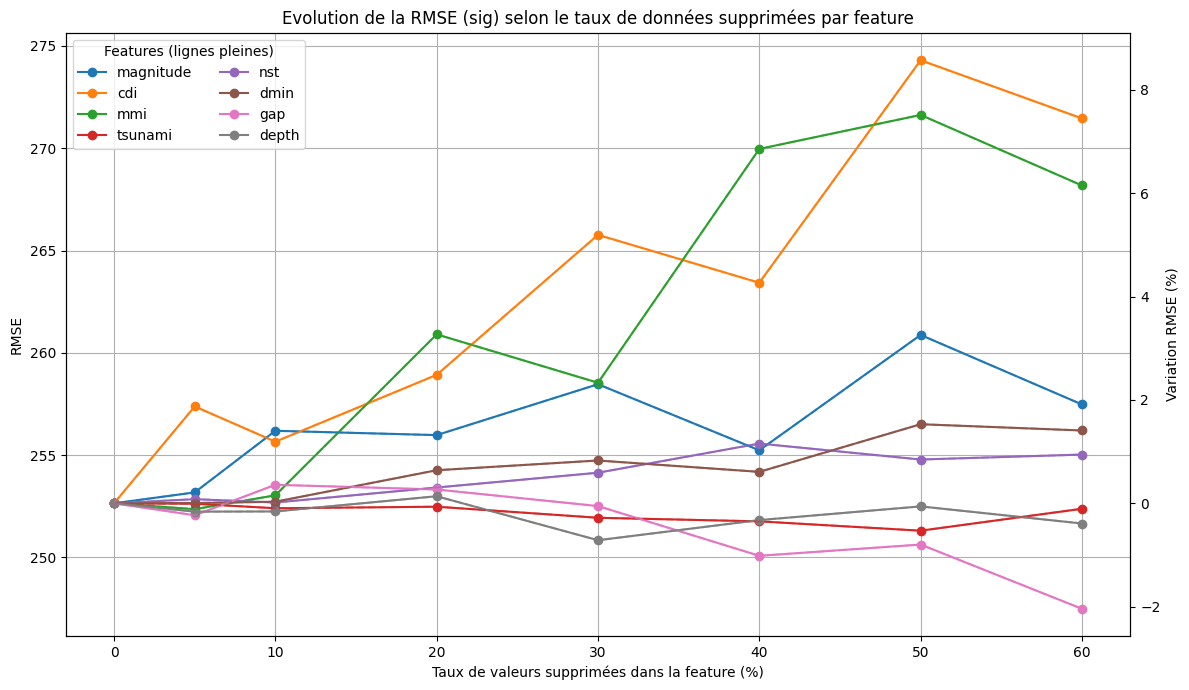

,0%,5%,10%,20%,30%,40%,50%,60%
magnitude,252.642475,253.175394,256.187548,255.976452,258.464032,255.233750,260.872673,257.474474
cdi,252.642475,257.377287,255.653763,258.921210,265.764345,263.423739,274.299640,271.455920
mmi,252.642475,252.356121,253.032693,260.900934,258.535324,269.965035,271.627281,268.178809
tsunami,252.642475,252.622288,252.400763,252.476088,251.935769,251.759784,251.303929,252.375533
nst,252.642475,252.845087,252.680711,253.414046,254.137668,255.563484,254.782950,255.024958
dmin,252.642475,252.655556,252.719561,254.259077,254.735449,254.179960,256.508247,256.201989
gap,252.642475,252.058078,253.547988,253.317774,252.507227,250.076504,250.626786,247.486234
depth,252.642475,252.235154,252.244628,252.988015,250.837824,251.822207,252.491434,251.655503


In [15]:
def impute_and_scale_with_artifacts(X_df: pd.DataFrame, artifacts: dict):
    numeric_cols = artifacts["numeric_cols"]
    categorical_cols = artifacts["categorical_cols"]
    imputer_num = artifacts["imputer_num"]
    imputer_cat = artifacts["imputer_cat"]
    scaler = artifacts["scaler"]
    feature_order = artifacts["feature_order"]

    X_num = pd.DataFrame(imputer_num.transform(X_df[numeric_cols]), columns=numeric_cols, index=X_df.index)

    if categorical_cols:
        X_cat = pd.DataFrame(imputer_cat.transform(X_df[categorical_cols]), columns=categorical_cols, index=X_df.index)
        X_imp = pd.concat([X_num, X_cat], axis=1)[feature_order]
    else:
        X_imp = X_num[feature_order]

    return scaler.transform(X_imp)


def rmse_curve_by_feature(
    model,
    X_test_raw: pd.DataFrame,
    y_test: pd.Series,
    artifacts: dict,
    missing_rates,
    random_state: int = 42,
):
    rng = np.random.default_rng(random_state)
    feature_names = X_test_raw.columns.tolist()

    rmse_per_feature = {}

    for feat in feature_names:
        feature_curve = []

        for rate in missing_rates:
            temp = []
            for i in range(10):
                X_missing = X_test_raw.copy()
                n_rows = len(X_missing)
                n_drop = int(np.floor(rate * n_rows))

                if n_drop > 0:
                    idx_missing = rng.choice(n_rows, size=n_drop, replace=False)
                    rows = X_missing.index[idx_missing]
                    X_missing.loc[rows, feat] = np.nan

                X_scaled = impute_and_scale_with_artifacts(X_missing, artifacts)
                y_pred = model.predict(X_scaled)
                rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
                temp.append(rmse)
            rmse = float(np.mean(temp))
            feature_curve.append(rmse)

        rmse_per_feature[feat] = feature_curve

    return rmse_per_feature


missing_rates = np.array([0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60])
rmse_by_feature_sig = rmse_curve_by_feature(
    model_sig,
    X_test_s,
    y_test_s,
    preproc_sig,
    missing_rates,
    random_state=42,
)

fig, ax_rmse = plt.subplots(figsize=(12, 7))
ax_pct = ax_rmse.twinx()

for feature_name, rmse_curve in rmse_by_feature_sig.items():
    rmse_arr = np.asarray(rmse_curve, dtype=float)
    line_rmse, = ax_rmse.plot(missing_rates * 100, rmse_arr, marker="o", label=feature_name)

    rmse_baseline = rmse_arr[0]
    if np.isclose(rmse_baseline, 0.0):
        rmse_pct_change = np.full_like(rmse_arr, np.nan)
    else:
        rmse_pct_change = ((rmse_arr - rmse_baseline) / rmse_baseline) * 100.0

    ax_pct.plot(
        missing_rates * 100,
        rmse_pct_change,
        linestyle="--",
        alpha=0.5,
        color=line_rmse.get_color(),
    )

ax_rmse.set_title("Evolution de la RMSE (sig) selon le taux de données supprimées par feature")
ax_rmse.set_xlabel("Taux de valeurs supprimées dans la feature (%)")
ax_rmse.set_ylabel("RMSE")
ax_pct.set_ylabel("Variation RMSE (%)")
ax_rmse.grid(True)
ax_rmse.legend(ncol=2, title="Features (lignes pleines)")
plt.tight_layout()
plt.show()

pd.DataFrame(rmse_by_feature_sig, index=[f"{int(r*100)}%" for r in missing_rates]).T

## Conclusion

### Robustesse par forêt d'isolation

**Modèle `sig` (régression — RandomForestRegressor)**  
La RMSE reste globalement stable jusqu'à des seuils où la couverture est trop faible pour qu'ils soient retenus. Le seuil manuel retenu (`th_sig = -0.618`) constitue un bon compromis : il écarte les observations dont les scores d'anomalie sont les plus faibles, tout en maintenant une couverture élevée (>98 %) et une baisse de 4% de la RMSE.

**Modèle `alert` (classification — LogisticRegression)**  
Ici en revanche les résultats sont plus difficiles à interpréter, probablement par manque de données dans les classes les autres que `green`. Dans tous les cas on observe une diminution du F1-score plus le seuil d'isolation choisi est élevé. Pour cette raison, on retient un seuil manuel de (`th_alert = -1`) qui évite toute isolation et dégradation des performances.

### Robustesse à l'imputation (données manquantes)

Les courbes RMSE par feature montrent que le modèle `sig` est globalement robuste à l'imputation pour la plupart des features, même jusqu'à 60% d'imputation. \
Pour les features les plus impactantes (`mmi`, `cdi` et `magnitude`), l'augmentation de la RMSE (+2%) commence à être significative au delà de 20% d'imputations. \
Globalement le modèle est assez robuste à l'imputation.
